# Amazon Renewed Phone Price Analysis

Methodology & Dataset

Source: Real price data extracted via the Keepa API.
Market: Amazon US (Refurbished / Secondary Market).
Scope: 3 major brands (Apple, Samsung, Google) across 63 submodels.
Volume: Roughly 878,000 weekly price records spanning from 2019 to 2026.

It starts with a macro-level comparison between brands, followed by a deep dive into iPhones.

The central question is pretty simple: once a phone hits the secondary market, how fast does
it lose value, and does it depend on the brand, the model tier, or the time of year? Are there any observable patterns and relations between the brands and submodels?

**A few notes**

Data was fetched via the Keepa API around February 2026, stored in a local PostgreSQL database, and explored using SQL aggregations and views and I also created some data visualizations in Power BI.

Then I had a break as I focused on different projects, but at the beginning of May I decided the project will instead be a Python-focused analysis, which will become one of my portfolio projects, as well as a perfect fit for Crappy Data Python for DA course projects.

Roughly 70–80% of the project timeline was dedicated to iterative EDA, testing different aggregation levels, mapping edge cases, adjusting my choices and handling different issues, with a few setbacks as well.

In the end, I've opted for relative values (% of the launch price vs raw $), but I'm also thinking about including the latter in my analysis.

Some of the challenges I've encountered:

- Each product variant (e.g. iPhone 14 128GB Red Renewed Premium) had its own ASIN code and data tracked only for that particular model, storage size and color. I had to identify that and really consider how to aggregate data
- Datetimes from the API were given with a custom epoch - number of minutes from 2011-01-01 (so called KeepaTime)
- Price tracking history had gaps between the premiere and the actual tracking - this is most likely due to the fact that we're tracking the secondary market
- Price values were divided by 100
- Monthly_sold shows the bottom value of a range of goods sold rather than precise numbers. For example, 50 means it could be anywhere between 50 and 99 etc. For that reason, this has to be treated as a relative indicator rather than a precise measurement, but it's enough to make comparisons between different smartphones, as all of them have sales quantity measured in the same way.

The analysis strictly covers Amazon Renewed listings. For Apple, this captures the full secondary market on Amazon US. For Samsung and Google, New and Renewed listings are separated where relevant.

Launch prices were manually sourced from official press releases using the mean price across all storage tiers (e.g., iPhone 16 Pro reference price is set at $1,224).

The most recent releases (e.g., iPhone 17) were omitted from price decay models due to insufficient data history.

## Data import with preview and aggregation

Below is the final code used for data import and aggregation. To keep this report concise, I have excluded the initial exploration and cleaning phases, which involved multiple iterations across different notebooks. During that process, I tested various paths and adjusted the methodology whenever the raw data showed inconsistencies or required a change in approach.

What follows is the refined, logical structure of the final dataset. For context, I’ve included a quick preview of the three primary files used in this analysis before diving into the aggregation logic.


In [24]:
#Imports + data loading with data preview

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sns.set_theme(style='whitegrid')

data_folder = '../data/'
for file in os.listdir(data_folder):
    if 'price_history_full' in file:
        df = pd.read_csv(data_folder + file)

original_launch_ref = pd.read_csv('../data/official_launch_prices.csv')
ms_df = pd.read_csv('../data/monthly_sold_full.csv')

print(df.head())
print(original_launch_ref.head())
print(ms_df.head())

         asin  storage_gb   color    product_grade submodel_name  brand  \
0  B011SDYBZW        64.0  Purple  Renewed Premium     iPhone 11  Apple   
1  B011SDYBZW        64.0  Purple  Renewed Premium     iPhone 11  Apple   
2  B011SDYBZW        64.0  Purple  Renewed Premium     iPhone 11  Apple   
3  B011SDYBZW        64.0  Purple  Renewed Premium     iPhone 11  Apple   
4  B011SDYBZW        64.0  Purple  Renewed Premium     iPhone 11  Apple   

  generation_name premiere_date             datetime  new_price  amazon  \
0       iPhone 11    2019-09-20  2021-07-02 15:36:00       5.69    5.69   
1       iPhone 11    2019-09-20  2021-07-09 18:36:00       5.51    5.51   
2       iPhone 11    2019-09-20  2021-07-23 10:36:00       5.69    5.69   
3       iPhone 11    2019-09-20  2021-07-24 07:36:00       5.29    5.29   
4       iPhone 11    2019-09-20  2021-08-06 09:32:00       5.69    5.69   

   used_price  list_price  sales_rank  count_new  count_used  
0         NaN         NaN         N

In [2]:

# Data aggregation continued

df = df.merge(original_launch_ref, on='submodel_name')
df['official_premiere_date'] = pd.to_datetime(df['official_premiere_date'])
df['datetime'] = pd.to_datetime(df['datetime'])
df['days_since_launch'] = (df['datetime'] - df['official_premiere_date']).dt.days
df = df[df['days_since_launch'] > 0]
df['NEW'] = df['new_price'] * 100
df = df.drop('new_price', axis=1)
df['price_pct_of_launch'] = round(df['NEW'] / df['official_launch_price'] * 100, 1)
df['days_rounded'] = (df['days_since_launch'] / 7).round() * 7 #required to deal with splitting/duplicated lines on the charts later as there are data points with no equivalents, so they create new lines
df['tier'] = df.apply(lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(), axis=1)
df['tier'] = df['tier'].replace('', 'Base')


# price decay dataframes
base_apple_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Apple') & (df['generation_name'] != 'iPhone 17')]
base_apple_decay_df = base_apple_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

base_samsung_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Samsung')]
base_samsung_decay_df = base_samsung_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

base_google_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Google')]
base_google_decay_df = base_google_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

base_combined_df = df[df['tier'] == 'Base']
all_brands_decay_df = base_combined_df.groupby(['brand', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

grouped_generation_decay_df = df.groupby(['submodel_name', 'generation_name', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()
iphone13_decay_df = grouped_generation_decay_df[grouped_generation_decay_df['generation_name'] == 'iPhone 13']
 
 
 
# 1-year retention
retention_1yr_df = df[(df['days_rounded'] > 330) & (df['days_rounded'] < 380)]
retention_1yr_df = retention_1yr_df.groupby('generation_name').agg(
    price_retention=('price_pct_of_launch', 'mean'),
    brand=('brand', 'first')
).reset_index().sort_values('price_retention', ascending=False)

brand_retention_1yr = retention_1yr_df.groupby('brand')['price_retention'].mean()
apple_retention_1yr = brand_retention_1yr['Apple']
samsung_retention_1yr = brand_retention_1yr['Samsung']
google_retention_1yr = brand_retention_1yr['Google']


grade_means = df[(df['tier'] == 'Base') & (df['brand'] == 'Apple')].groupby('product_grade')['price_pct_of_launch'].mean()
renewed_premium_premium = grade_means['Renewed Premium'] - grade_means['Renewed']

#Launch ref tiers added for flagship vs base official launch prices comaprison
gen_lookup = df[['submodel_name', 'generation_name', 'brand']].drop_duplicates()
launch_ref = original_launch_ref.copy().merge(gen_lookup, on='submodel_name', how='left')
launch_ref['tier'] = launch_ref.apply(lambda row: row['submodel_name'].replace(str(row['generation_name']), '').strip(), axis=1)
launch_ref['tier'] =  launch_ref['tier'].replace('', 'Base')

launch_ref['official_premiere_date'] = pd.to_datetime(launch_ref['official_premiere_date'])
base_launch_ref = launch_ref[launch_ref['tier'] == 'Base']
flagship_launch_ref = launch_ref[(launch_ref['tier'] == 'Pro Max') | (launch_ref['tier'] == 'Ultra') | (launch_ref['tier'] == 'Pro XL') | (launch_ref['tier'] == 'Ultra') | ((launch_ref['tier'] == 'Pro') & (launch_ref['brand'] == 'Google'))]

#tier aggregation for price decay
all_brands_tier_price_decay_df = df.groupby(['brand', 'tier', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()
apple_tier_price_decay_df = all_brands_tier_price_decay_df[all_brands_tier_price_decay_df['brand'] == 'Apple']
samsung_tier_price_decay_df = all_brands_tier_price_decay_df[all_brands_tier_price_decay_df['brand'] == 'Samsung']
google_tier_price_decay_df = all_brands_tier_price_decay_df[all_brands_tier_price_decay_df['brand'] == 'Google']


#price decay data in USD + brand-specific dfs for base + flagship + two interesting price decay examples (Google Pro Fold and Samsung Edge)
dollar_all_brands_price_decay_df = df.groupby(['brand', 'submodel_name', 'days_rounded', 'tier'])['NEW'].mean().reset_index()

apple_dollar_price_decay_df = dollar_all_brands_price_decay_df[(dollar_all_brands_price_decay_df['brand'] == 'Apple') & ((dollar_all_brands_price_decay_df['tier'] == 'Base') | (dollar_all_brands_price_decay_df['tier'] == 'Pro Max'))]
samsung_dollar_price_decay_df = dollar_all_brands_price_decay_df[(dollar_all_brands_price_decay_df['brand'] == 'Samsung') & ((dollar_all_brands_price_decay_df['tier'] == 'Base') | (dollar_all_brands_price_decay_df['tier'] == 'Ultra') | (dollar_all_brands_price_decay_df['tier'] == 'Edge'))]
google_dollar_price_decay_df = dollar_all_brands_price_decay_df[(dollar_all_brands_price_decay_df['brand'] == 'Google') & ((dollar_all_brands_price_decay_df['tier'] == 'Base') | (dollar_all_brands_price_decay_df['tier'] == 'Pro') | (dollar_all_brands_price_decay_df['tier'] == 'Pro Fold'))]



#5.06.26 - sales rank data rechecked from scratch

# load monthly sold
ms_df = ms_df.merge(original_launch_ref, on='submodel_name', how = 'left')
ms_df['official_premiere_date'] = pd.to_datetime(ms_df['official_premiere_date'])
ms_df['datetime'] = pd.to_datetime(ms_df['datetime'])
del ms_df['premiere_date']
ms_df['days_since_launch'] = (ms_df['datetime'] - ms_df['official_premiere_date']).dt.days
ms_df['days_rounded'] = (ms_df['days_since_launch'] / 7).round() * 7 #required to deal with splitting/duplicated lines on the charts later as there are data points with no equivalents, so they create new lines
ms_df = ms_df[ms_df['days_since_launch'] >= 0]
ms_df['tier'] = ms_df.apply(lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(), axis=1)
ms_df['tier'] = ms_df['tier'].replace('', 'Base')



#New monthly sales rank dataframes
new_ms_df = ms_df.copy().set_index(ms_df['datetime'])
new_ms_df = new_ms_df.groupby('asin').resample('ME').last() #the last monthly record for each asin, as the monthly_sales records are updated
new_ms_df = new_ms_df[(new_ms_df['submodel_name'].notna()) & (new_ms_df['monthly_sold'] >= 0)]

new_ms_df['month_year'] = new_ms_df['datetime'].dt.to_period('M').dt.to_timestamp()

brand_ms_df = new_ms_df.groupby(['brand', 'month_year'])['monthly_sold'].sum().reset_index()
brand_tier_ms_df = new_ms_df.groupby(['brand', 'tier', 'month_year'])['monthly_sold'].sum().reset_index()
submodel_ms_df = new_ms_df.groupby(['brand', 'submodel_name', 'tier', 'generation_name', 'month_year'])['monthly_sold'].sum().reset_index()

apple_base_ms_df = submodel_ms_df[(submodel_ms_df['brand'] == 'Apple') & ((submodel_ms_df['tier'] == 'Base'))]

apple_ms_df = brand_tier_ms_df[(brand_tier_ms_df['brand'] == 'Apple') & ((brand_tier_ms_df['tier'] == 'Base') | (brand_tier_ms_df['tier'] == 'Pro Max'))]
samsung_ms_df = brand_tier_ms_df[(brand_tier_ms_df['brand'] == 'Samsung') & ((brand_tier_ms_df['tier'] == 'Base') | (brand_tier_ms_df['tier'] == 'Ultra') | (brand_tier_ms_df['tier'] == 'Edge'))]
google_ms_df = brand_tier_ms_df[(brand_tier_ms_df['brand'] == 'Google') & ((brand_tier_ms_df['tier'] == 'Base') | (brand_tier_ms_df['tier'] == 'Pro') | (brand_tier_ms_df['tier'] == 'Pro Fold'))]

iphone11_ms_df = submodel_ms_df[submodel_ms_df['generation_name'] == 'iPhone 11']
iphone13_ms_df = submodel_ms_df[submodel_ms_df['generation_name'] == 'iPhone 13']
iphone15_ms_df = submodel_ms_df[submodel_ms_df['generation_name'] == 'iPhone 15']


---
## Project Overview

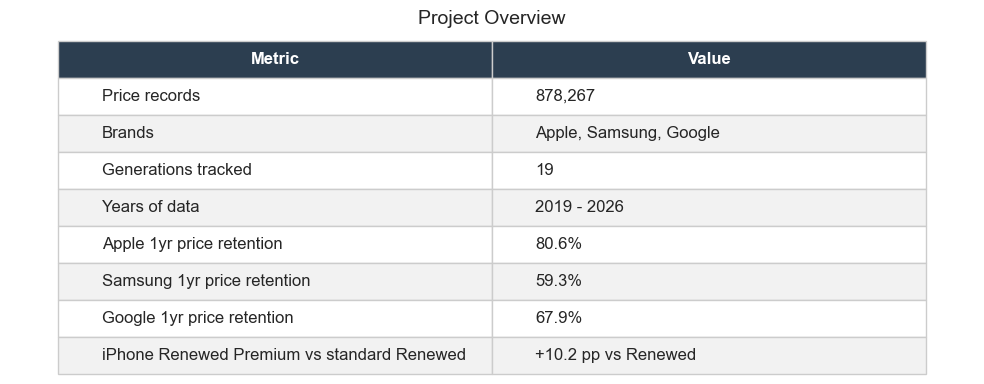

In [3]:
kpi_data = [
    ['Price records', '878,267'],
    ['Brands', 'Apple, Samsung, Google'],
    ['Generations tracked', str(df['generation_name'].nunique())],
    ['Years of data', '2019 - 2026'],
    ['Apple 1yr price retention', f'{round(apple_retention_1yr, 1)}%'],
    ['Samsung 1yr price retention', f'{round(samsung_retention_1yr, 1)}%'],
    ['Google 1yr price retention', f'{round(google_retention_1yr, 1)}%'],
    ['iPhone Renewed Premium vs standard Renewed', f'+{round(renewed_premium_premium, 1)} pp vs Renewed'],
]

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
table = ax.table(
    cellText=kpi_data,
    colLabels=['Metric', 'Value'],
    cellLoc='left',
    loc='center',
    colWidths=[0.45, 0.45]
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2.2)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f2f2f2')
    else:
        cell.set_facecolor('white')

plt.title('Project Overview', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


---
# Price Decay analysis

Each chart below shows price as a percentage of the official launch price over time.
100% means the phone is still at its launch price on the Renewed market, 50% means it's
lost half its value. The x-axis shows days since launch so models can be compared at the
same point in their lifecycle regardless of when they were released.

## Official launch prices
These launch prices were calculated as mean of all relevant memory sizes for a given submodel.

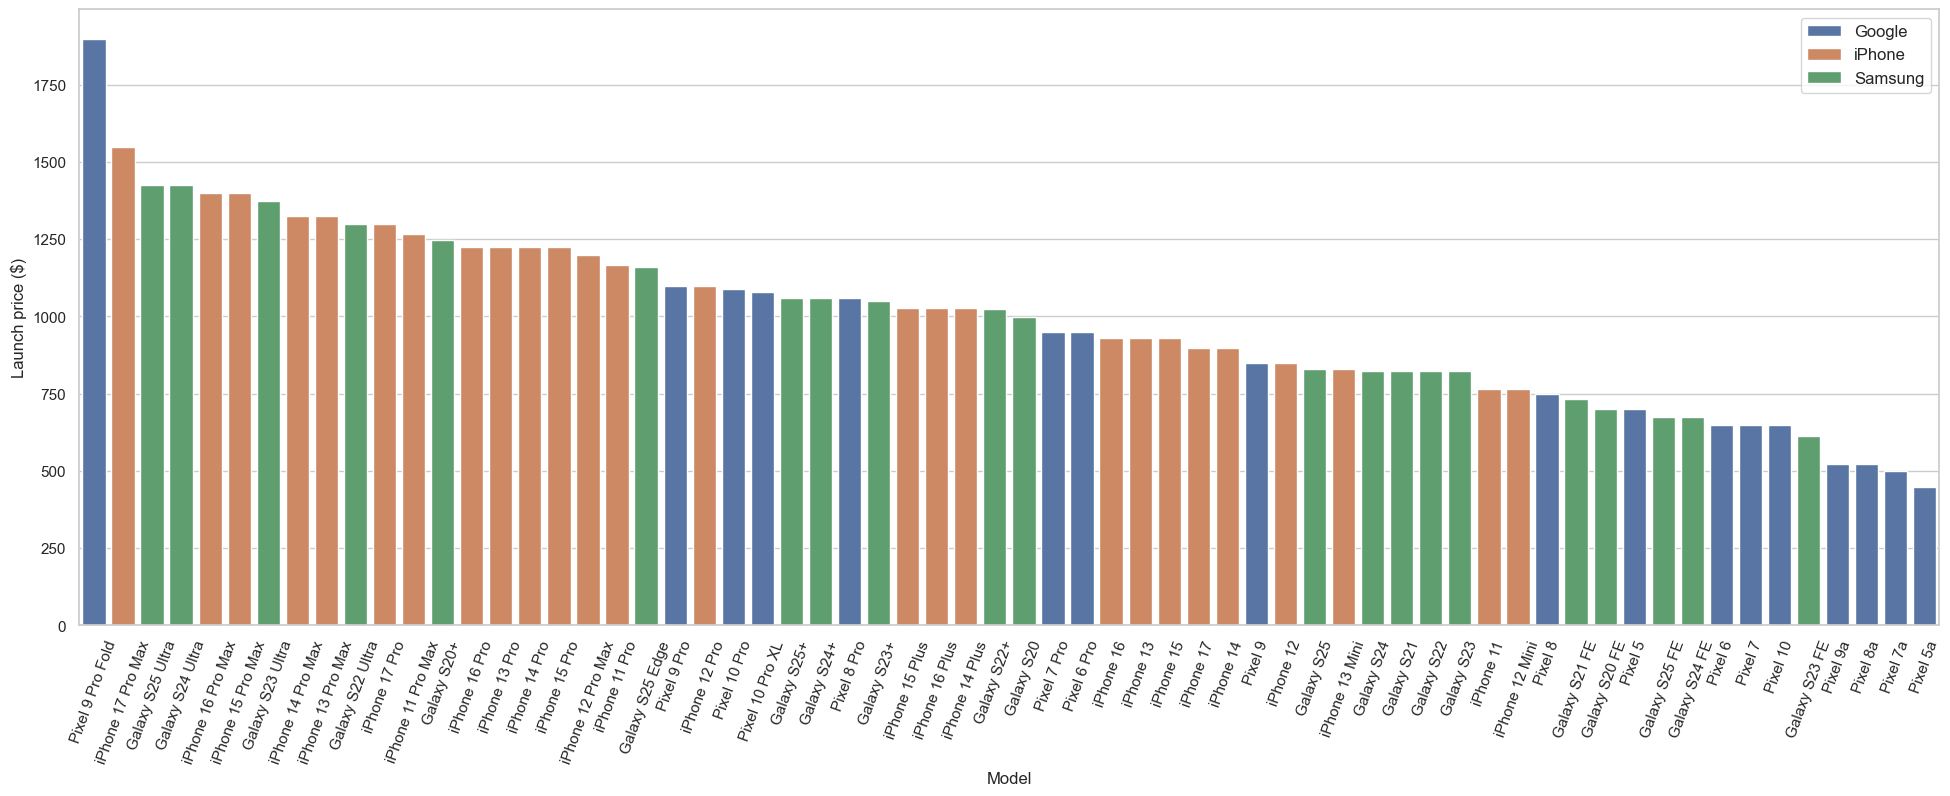

In [4]:
launch_ref['brand'] = launch_ref['submodel_name'].str.split().str[0]
launch_ref['brand'] = launch_ref['brand'].replace(['Pixel', 'Galaxy'], ['Google', 'Samsung'])
launch_ref = launch_ref.sort_values(by = 'official_launch_price', ascending = False)


plt.subplots(figsize = (24, 8))
launch_price_chart = sns.barplot(
    data = launch_ref,
    x = 'submodel_name',
    y = 'official_launch_price',
    hue = 'brand'
)

plt.legend(loc = 'upper right', fontsize = 12)
plt.xticks(rotation = 70)
plt.xlabel('Model')
plt.ylabel('Launch price ($)')
plt.show()

Below is a comparison of the official launch prices across all brands. The first chart focuses on base models (e.g., iPhone 15, Samsung Galaxy S22, Google Pixel 6), while the second highlights flagship submodels (iPhone Pro Max, Samsung Galaxy Ultra, Google Pixel Pro).

IMPORTANT NOTE: In Google's line, there is also the Pro Fold/Fold XL (it also takes #1 position in the chart above) which appeared for the first time in 2023, and is currently the most expensive version of Google Pixel Pro phone, but it is best understood as a premium form alternative rather than the absolute hardware pinnacle. While its $1,799 price tag reflects the complex engineering, flexible display, and R&D of a foldable, it actually compromises on traditional flagship metrics. Essentially, you are paying a massive premium for a versatile, pocketable tablet, but if your goal is the absolute best camera and performance hardware Google offers, the traditional Pixel Pro remains the true flagship.

Unlike Google’s Fold, the iPhone Pro Max and Samsung Galaxy Ultra are the undisputed, absolute hardware flagships of their respective brands with the best cameras, maximum efficiency and the largest batteries.

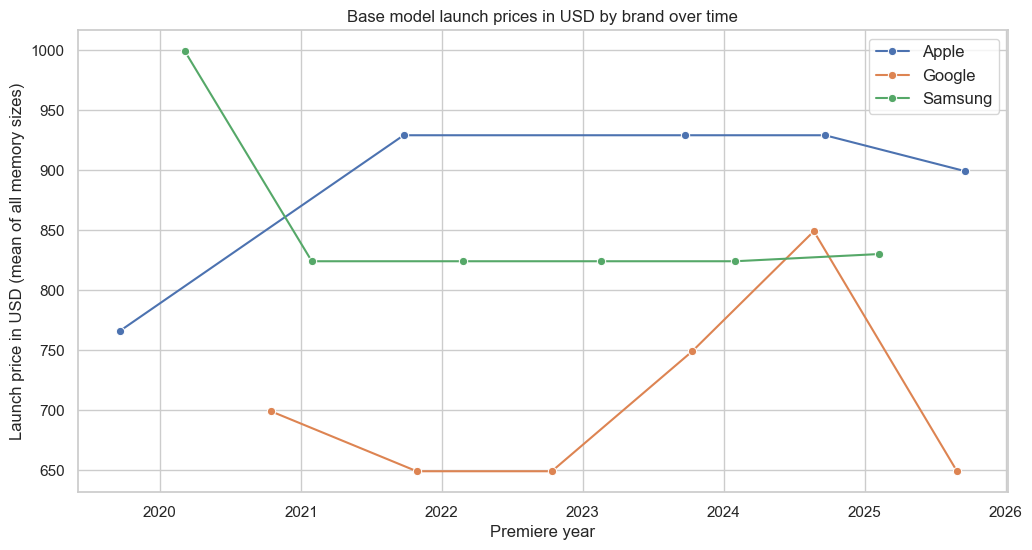

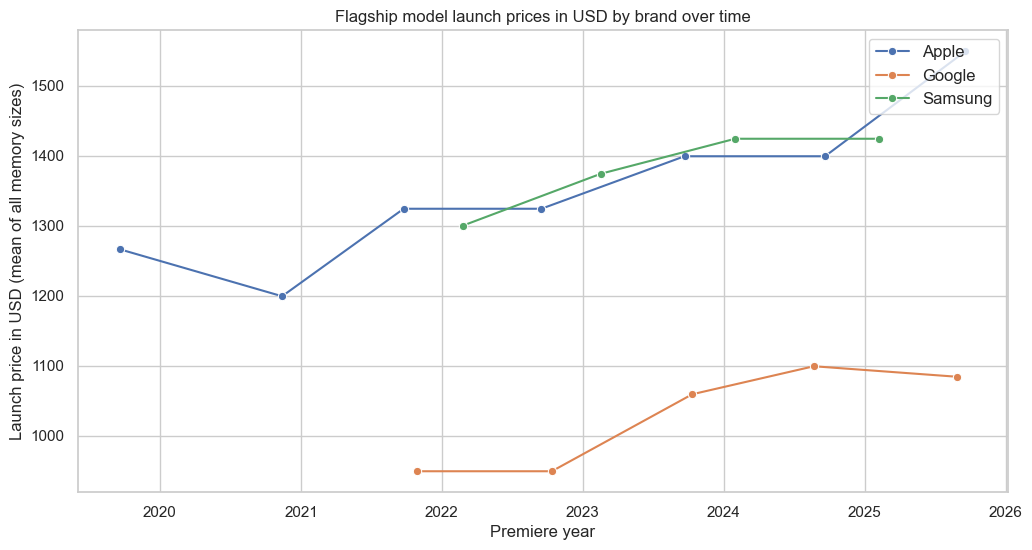

In [ ]:


plt.subplots(figsize = (12, 6))
base_launch_chart = sns.lineplot(
    data = base_launch_ref,
    x = 'official_premiere_date',
    y = 'official_launch_price',
    hue = 'brand',
    marker = 'o'
)
plt.legend(loc = 'upper right', fontsize = 12)
plt.xlabel('Premiere year')
plt.ylabel('Launch price in USD (mean of all memory sizes)')
plt.title('Base model launch prices in USD by brand over time')
plt.show()


plt.subplots(figsize = (12, 6))
flagship_launch_chart = sns.lineplot(
    data = flagship_launch_ref,
    x = 'official_premiere_date',
    y = 'official_launch_price',
    hue = 'brand',
    marker = 'o'
)
plt.legend(loc = 'upper right', fontsize = 12)
plt.xlabel('Premiere year')
plt.ylabel('Launch price in USD (mean of all memory sizes)')
plt.title('Flagship model launch prices in USD by brand over time')
plt.show()



Google consistently positions itself as the most budget-friendly choice. Across both flagship and base tiers, Google smartphones are generally priced about 20% lower than their competitors.

Samsung and Apple compete directly at the top of the market, Apple's base models are typically about 10% more expensive than Samsung's base models, but that gap disappears at the premium level. Samsung’s Ultra models are priced almost identically to Apple’s Pro Max variants.

**Base models combined for all brands**

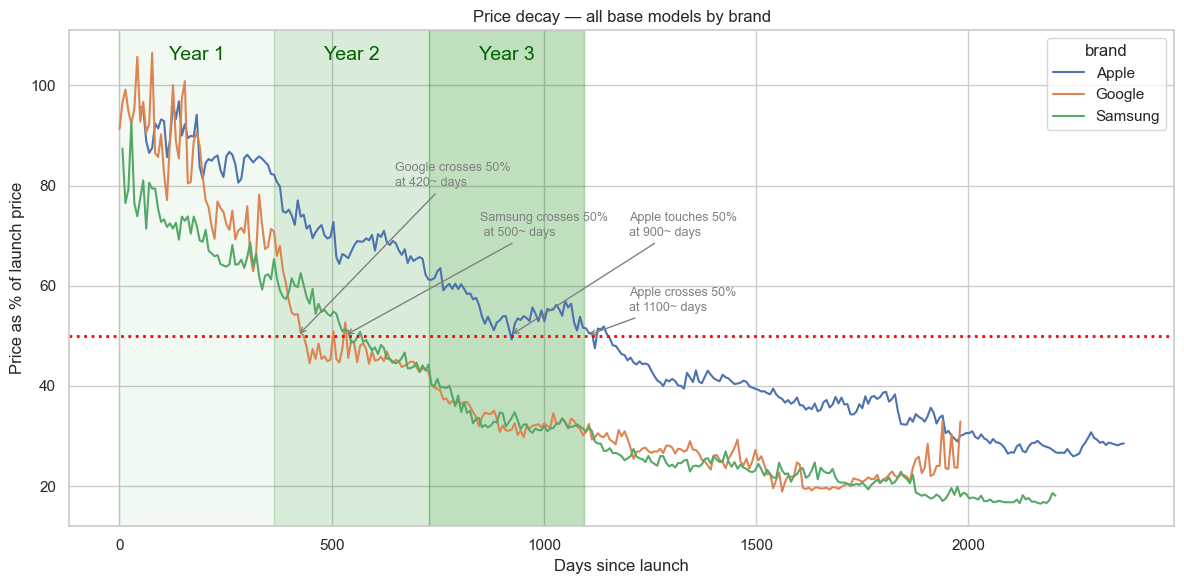

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_1d = sns.lineplot(data=all_brands_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='brand', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay — all base models by brand')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
plt.tight_layout()


plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 105, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 105, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 105, 'Year 3', fontsize=14, color='darkgreen', ha='center')


plt.annotate(
    'Samsung crosses 50%\n at 500~ days',
    xy=(530, 50),
    xytext=(850, 70),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)
plt.annotate(
    'Apple touches 50%\nat 900~ days',
    xy=(920, 50),
    xytext=(1200, 70),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)

plt.annotate(
    'Apple crosses 50%\nat 1100~ days',
    xy=(1100, 50),
    xytext=(1200, 55),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)

plt.annotate(
    'Google crosses 50%\nat 420~ days',
    xy=(420, 50),
    xytext=(650, 80),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)
plt.show()


The light shaded area highlights the first three years after launch.

Apple phones are the last to hit the 50% mark, getting there for the first time at around 900 days after launch, but then crossing it at about 1100 days mark.
Samsung reaches it at roughly 500 days, Google at around 420 days. Apple also has the highest
price floor, stabilising at 26-28% of launch price after about 2000 days. Samsung bottoms out
around 16-17% and Google around 20%.

**Apple base models by generation + all submodels**

iPhones on Amazon are sold as Renewed or Renewed Premium only. Solid lines are standard Renewed,
dashed lines are Renewed Premium. iPhone 17 is exclude (too little data at this point).

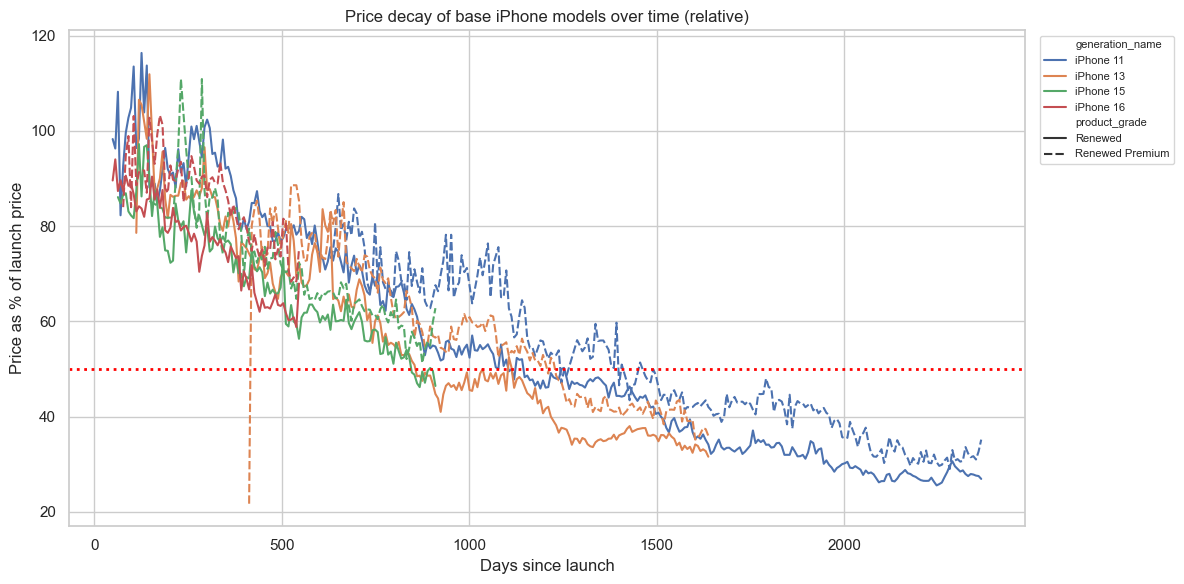

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_1 = sns.lineplot(data=base_apple_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='generation_name', style='product_grade', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay of base iPhone models over time (relative)')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


Renewed Premium consistently sits above the standard Renewed curve for the same generation.
The gap appears early and stays fairly stable throughout the lifecycle, which suggests buyers
pay a persistent condition premium regardless of how old the phone gets. The exact difference
varies by generation but averages around 10.2 percentage points.

**Samsung base models by generation**

Note: product_grade distinction was irrelevant here, as there were only Renewed sales with maybe one exception.

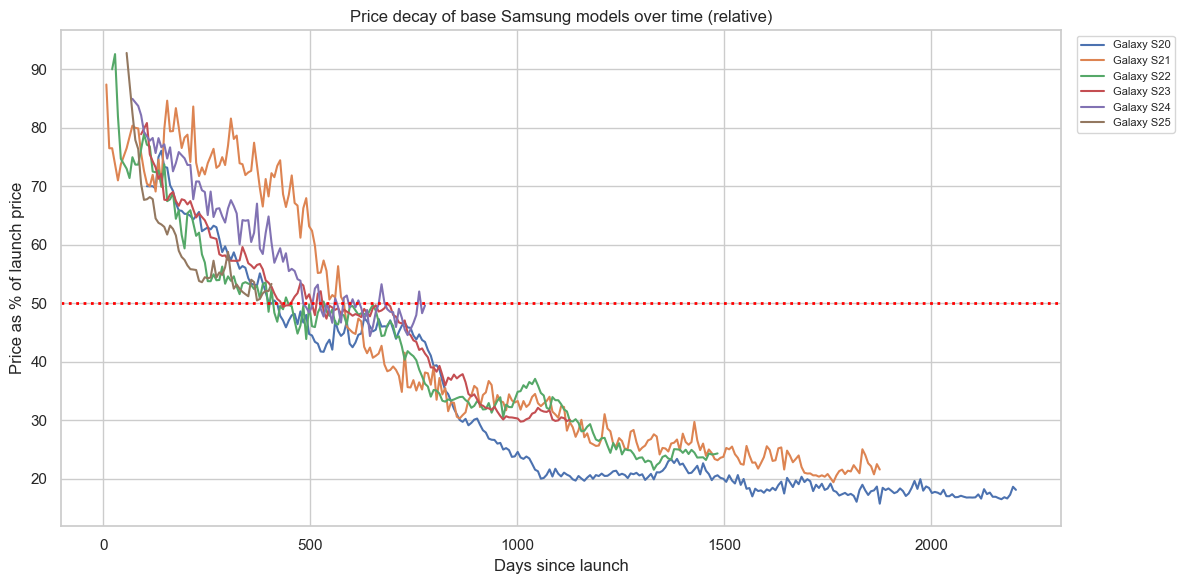

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_1b = sns.lineplot(data=base_samsung_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='generation_name', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay of base Samsung models over time (relative)')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


**Google Pixel price decay of base models by generation**


Note: as with Samsung, product_grade distinction was irrelevant here, as there were only Renewed sales with a few exceptions.

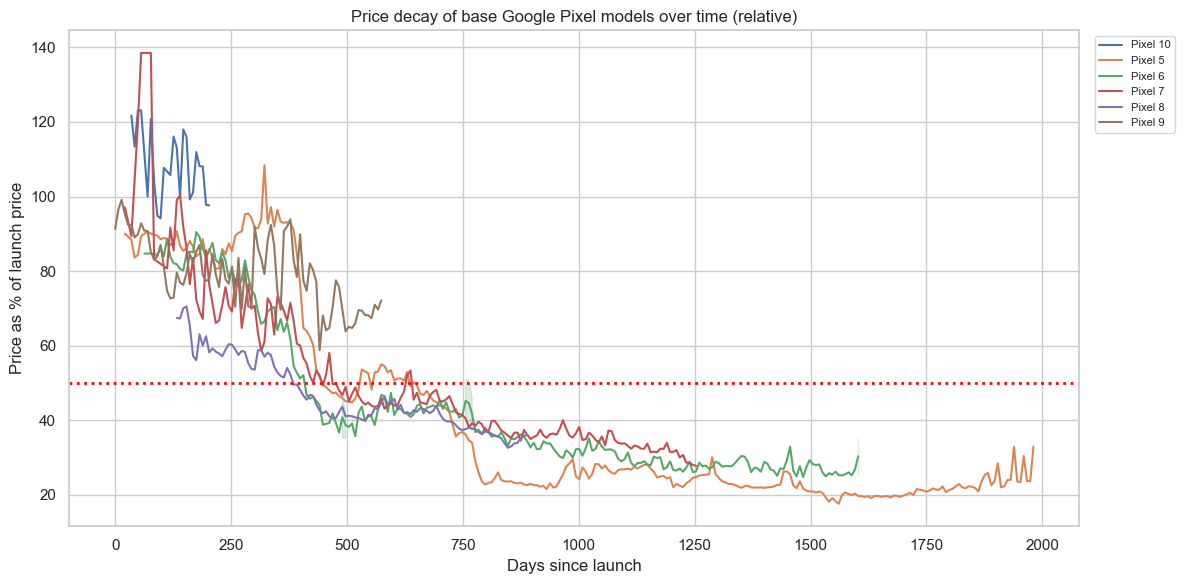

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_1c = sns.lineplot(data=base_google_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='generation_name', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay of base Google Pixel models over time (relative)')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


**Within a generation iPhone 13 submodels**

All tiers normalised to 100% at their own first recorded price, so you can compare decay
shape directly without the different launch prices distorting the picture.

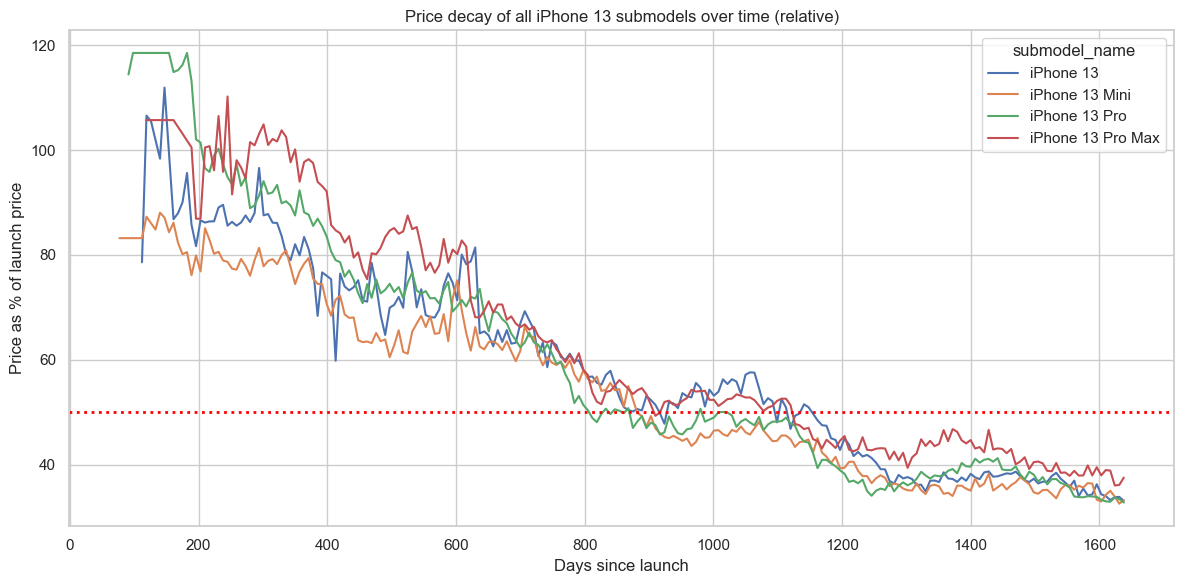

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_2 = sns.lineplot(data=iphone13_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='submodel_name', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay of all iPhone 13 submodels over time (relative)')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
plt.tight_layout()
plt.show()


The Pro Max consistently seems to be the strongest value-retaining submodel at almost every stage of the lifecycle as we look at iPhone 13. Remarkably, it retains roughly 40% of its launch price even at the 1600-day mark.

On the other end of the spectrum, the Mini submodel demonstrates faster depreciation, likely reflecting lower consumer demand and lower popularity.

## Price decay by tier

As we're already looked at how situation looks like for iPhone 13 submodels, let's now analyze all tiers performance for all the brands separately.

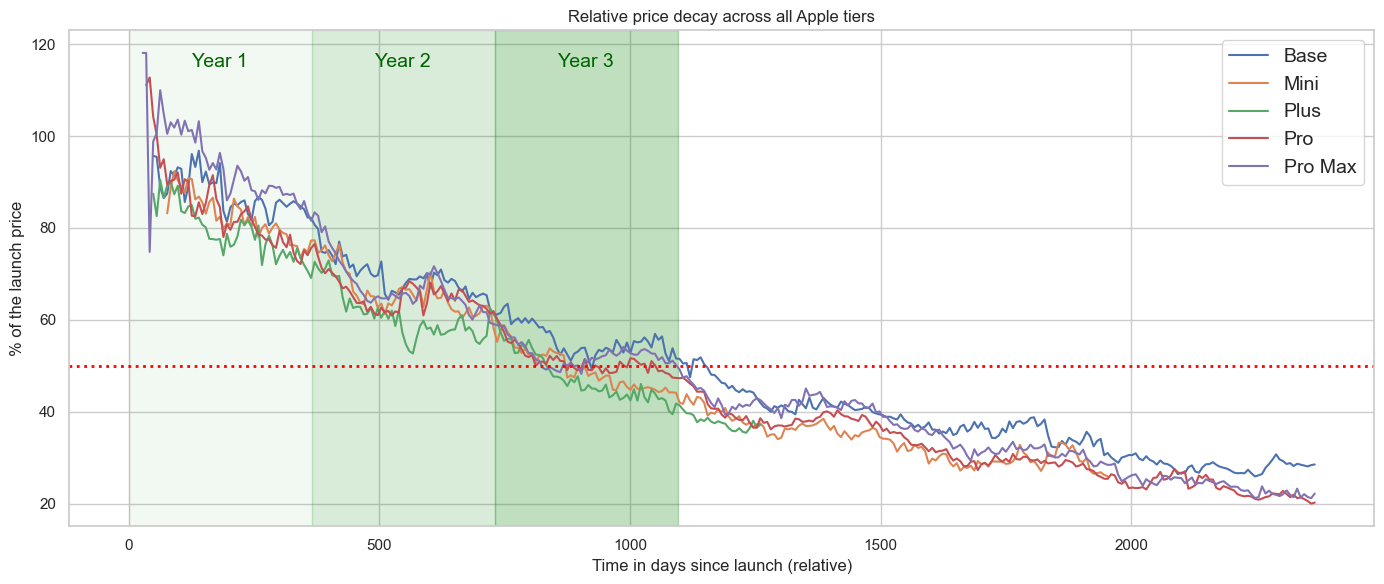

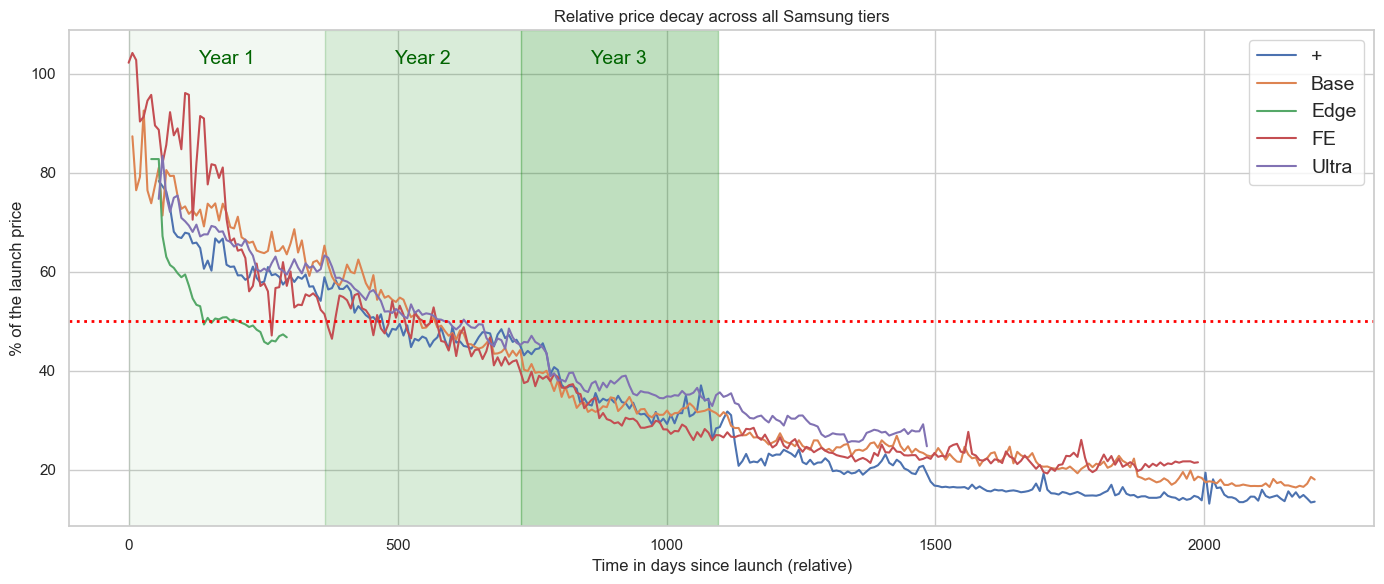

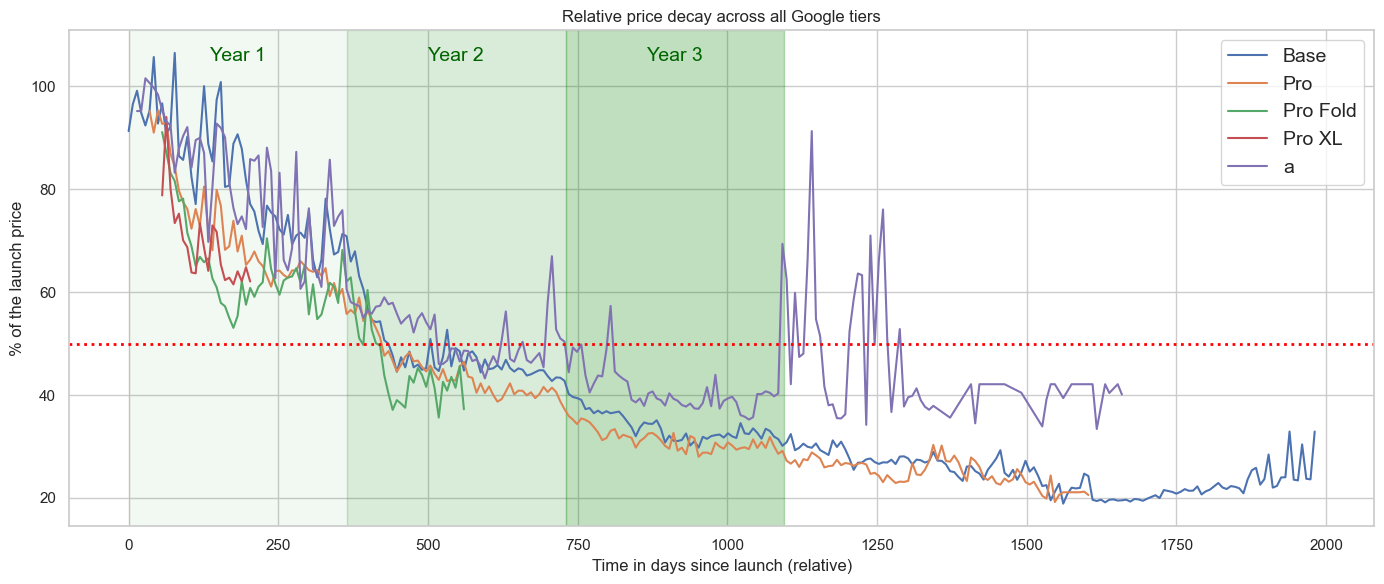

In [11]:

#Apple
plt.subplots(figsize = (14, 6))
pd_submodels_1a = sns.lineplot(
    apple_tier_price_decay_df,
    x = 'days_rounded',
    y = 'price_pct_of_launch',
    hue = 'tier'
)
plt.axhline(50, color='red', linestyle='dotted', linewidth=2)
plt.title('Relative price decay across all Apple tiers')
plt.xlabel('Time in days since launch (relative)')
plt.ylabel('% of the launch price')
plt.legend(loc = 'upper right', fontsize = 14)
plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 115, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 115, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 115, 'Year 3', fontsize=14, color='darkgreen', ha='center')

plt.show()



#Samsung
plt.subplots(figsize = (14, 6))
pd_submodels_1b = sns.lineplot(
    samsung_tier_price_decay_df,
    x = 'days_rounded',
    y = 'price_pct_of_launch',
    hue = 'tier'
)
plt.axhline(50, color='red', linestyle='dotted', linewidth=2)
plt.title('Relative price decay across all Samsung tiers')
plt.xlabel('Time in days since launch (relative)')
plt.ylabel('% of the launch price')
plt.legend(loc = 'upper right', fontsize = 14)
plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 102, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 102, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 102, 'Year 3', fontsize=14, color='darkgreen', ha='center')

plt.show()

#Google
plt.subplots(figsize = (14, 6))
pd_submodels_1c = sns.lineplot(
    google_tier_price_decay_df,
    x = 'days_rounded',
    y = 'price_pct_of_launch',
    hue = 'tier'
)
plt.axhline(50, color='red', linestyle='dotted', linewidth=2)
plt.title('Relative price decay across all Google tiers')
plt.xlabel('Time in days since launch (relative)')
plt.ylabel('% of the launch price')
plt.legend(loc = 'upper right', fontsize = 14)
plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 105, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 105, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 105, 'Year 3', fontsize=14, color='darkgreen', ha='center')

plt.show()



Contrary to expectations we have by looking at iPhone 13, the standard iPhone Base models exhibit the highest price stability across generations. While the Pro Max performs exceptionally well in specific intervals, the Base model consistently retains a higher percentage of its launch value over the long term.

Samsung displays distinct phases of price retention:
The FE (Fan Edition) and Base models lead in value retention during the first year.
Around day 500, the Ultra tier starts getting in and slowly overtakes the lineup to claim the highest value retention before data tracking concludes (at around 1500 day mark).
The Edge submodels exhibit an aggressively sharp price decay, which could be attributed to secondary market dynamics: the curved-display technology quickly lost its novelty as Samsung shifted focus to the Ultra series. Additionally, high repair costs and screen durability concerns among refurbished buyers severely suppressed long-term demand for the Edge.


Google’s lineup shows the sharpest polarization between tiers:
The budget-friendly Pixel 'a' series is the clear leader, and while it's also very volatile, it's consistently holding its value better than both the Base and Pro models.
Conversely, the Pro Fold, which was already mentioned in the official launch prices section (as it's the most expensive smartphone, but also not chosen as a flagship in this analysis), experiences one of the most severe and rapid depreciations in the entire dataset, failing to sustain its premium launch value over time.

## Price decay in USD

While looking at percentage drops is important, analyzing price decay in raw USD is vital. It provides a clear, real-world benchmark of what each brand or tier actually costs over time.

Below are the price decay charts in USD. First, you will see the average prices for all brands and tiers combined. After that, the charts break down the price decay for base and flagship models for each specific brand (Google chart also includes Pro Fold as an interesting example). Please note that these figures show the average price across all generations, storage options and colors, so actual prices may vary depending on the exact version.

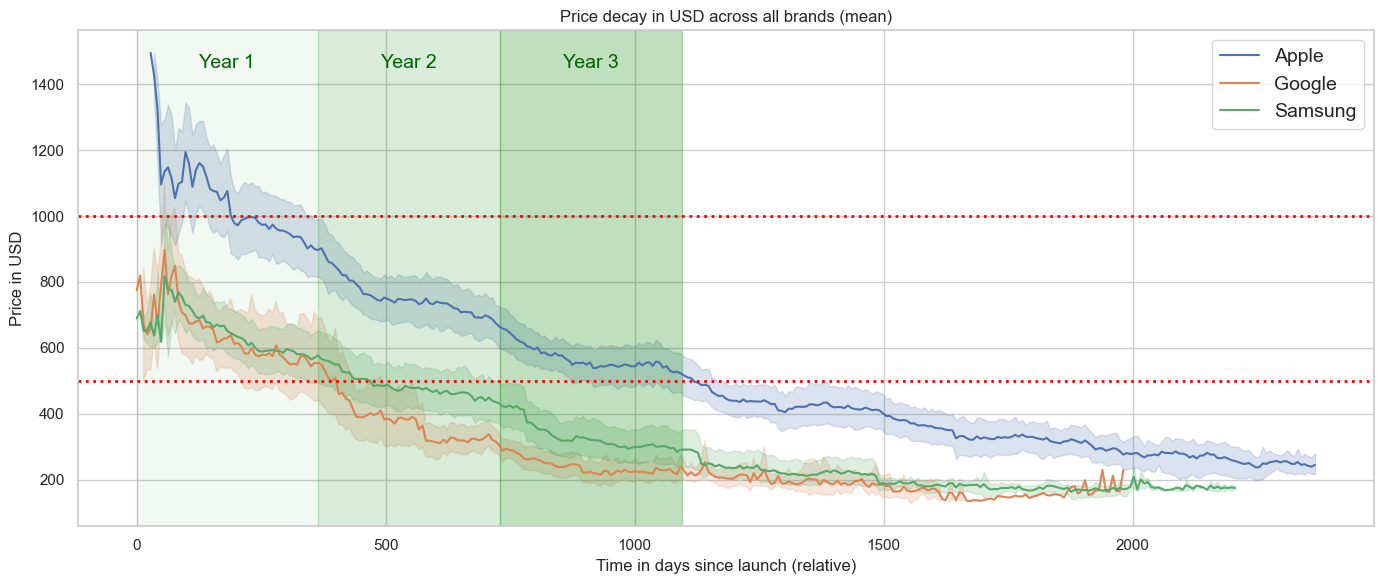

In [12]:


plt.subplots(figsize = (14, 6))
pd_dollar_chart1 = sns.lineplot(
    data = dollar_all_brands_price_decay_df,
    x = 'days_rounded',
    y = 'NEW',
    hue = 'brand'
)
plt.axhline(1000, color='red', linestyle='dotted', linewidth=2)
plt.axhline(500, color='red', linestyle='dotted', linewidth=2)
plt.title('Price decay in USD across all brands (mean)')
plt.xlabel('Time in days since launch (relative)')
plt.ylabel('Price in USD')
plt.legend(loc = 'upper right', fontsize = 14)
plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 1450, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 1450, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 1450, 'Year 3', fontsize=14, color='darkgreen', ha='center')

plt.show()





The above analysis expands on what we know about the price action of these brands.

Looking at the overall brand averages, Apple smartphones maintain a constant premium of about 200-400 USD over the competition throughout their entire lifecycle. At certain points, some iPhones can be as much as 100% more expensive than their direct competitors. Eventually, the average floor price for an iPhone stabilizes around 200-300 USD.

Google and Samsung both start at an average launch baseline of 700-800 USD. However, Samsung holds its value slightly better after the first year, maintaining a steady 100 USD premium over Google on average throughout the most of the lifecycle from that point. Samsung's floor price settles near 200 USD around 1,500 days after launch, while Google drops a bit lower to about 150-180 USD in the same timeframe.

Naturally, these brand-level charts use broad averages across all models and submodels, meaning they show general trends rather than exact calculations for a specific phone. It's also worth checking how the tiers perform within the brands.

----------------------------------------------------

#### Brand tier comparisons

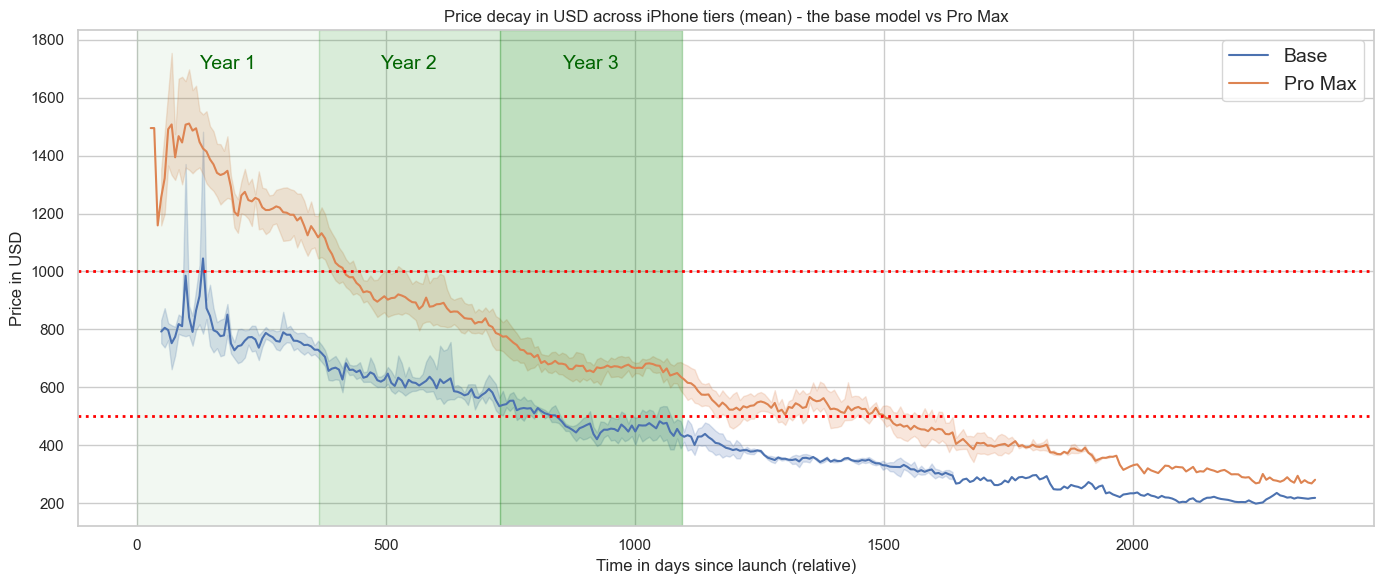

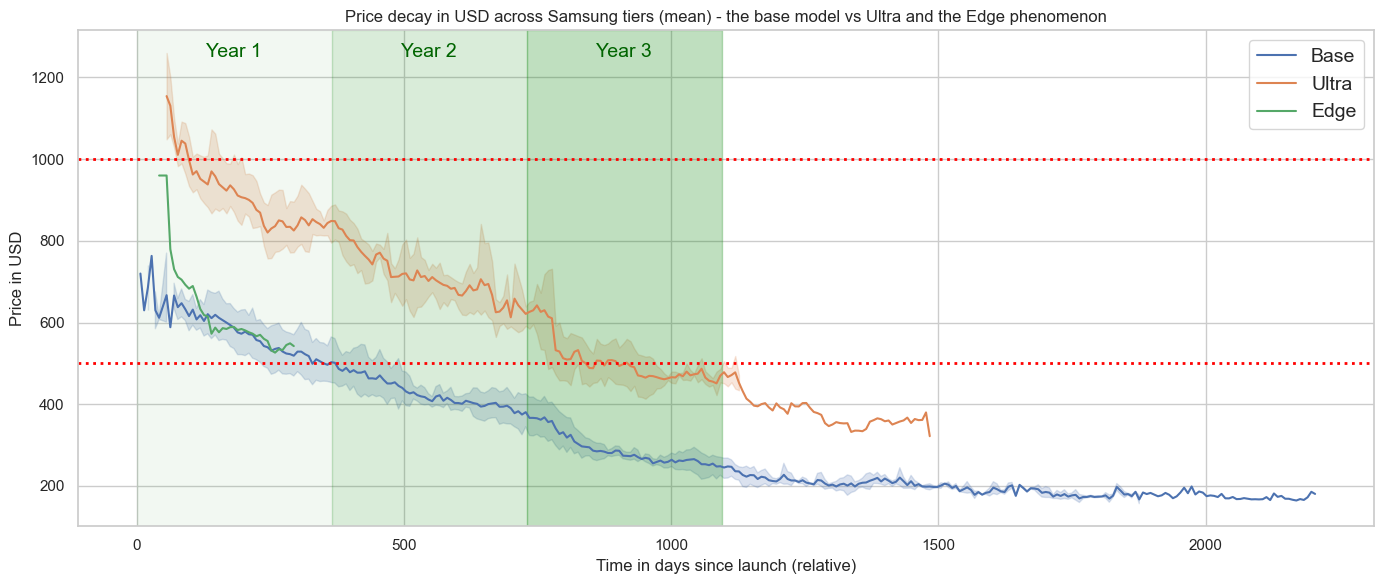

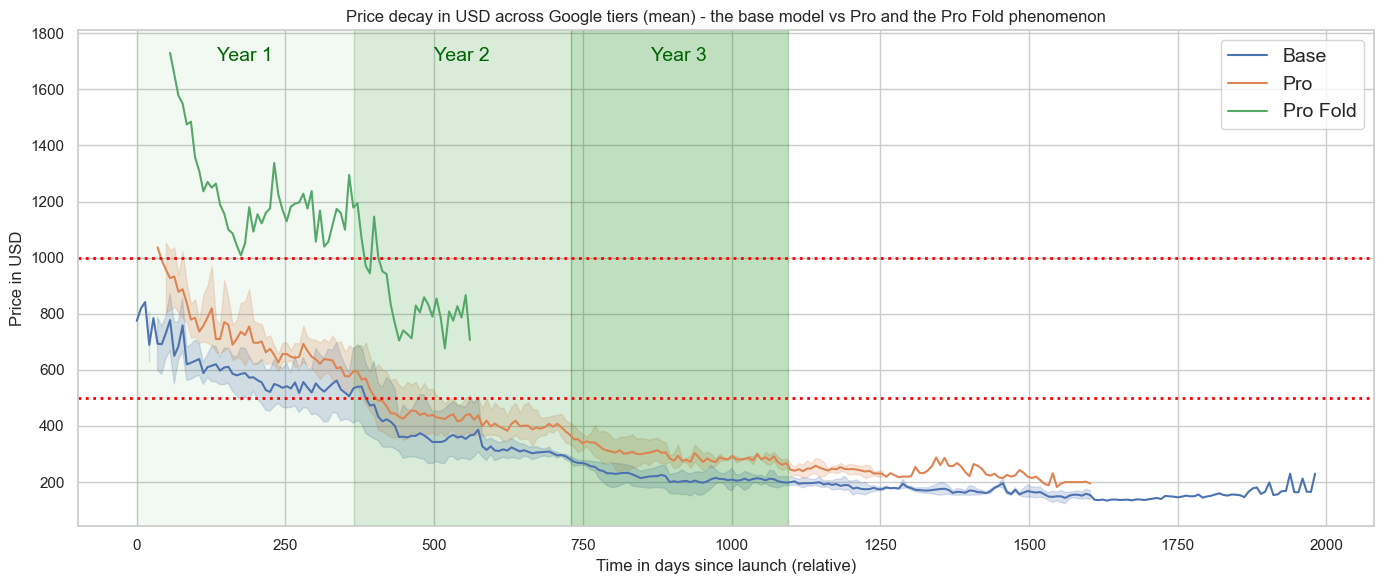

In [13]:
plt.subplots(figsize = (14, 6))
pd_dollar_chart1a = sns.lineplot(
    data = apple_dollar_price_decay_df,
    x = 'days_rounded',
    y = 'NEW',
    hue = 'tier'
)
plt.axhline(1000, color='red', linestyle='dotted', linewidth=2)
plt.axhline(500, color='red', linestyle='dotted', linewidth=2)
plt.title('Price decay in USD across iPhone tiers (mean) - the base model vs Pro Max')
plt.xlabel('Time in days since launch (relative)')
plt.ylabel('Price in USD')
plt.legend(loc = 'upper right', fontsize = 14)
plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 1700, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 1700, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 1700, 'Year 3', fontsize=14, color='darkgreen', ha='center')

plt.show()




plt.subplots(figsize = (14, 6))
pd_dollar_chart1b = sns.lineplot(
    data = samsung_dollar_price_decay_df,
    x = 'days_rounded',
    y = 'NEW',
    hue = 'tier'
)
plt.axhline(1000, color='red', linestyle='dotted', linewidth=2)
plt.axhline(500, color='red', linestyle='dotted', linewidth=2)
plt.title('Price decay in USD across Samsung tiers (mean) - the base model vs Ultra and the Edge phenomenon')
plt.xlabel('Time in days since launch (relative)')
plt.ylabel('Price in USD')
plt.legend(loc = 'upper right', fontsize = 14)
plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 1250, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 1250, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 1250, 'Year 3', fontsize=14, color='darkgreen', ha='center')

plt.show()





plt.subplots(figsize = (14, 6))
pd_dollar_chart1c = sns.lineplot(
    data = google_dollar_price_decay_df,
    x = 'days_rounded',
    y = 'NEW',
    hue = 'tier'
)
plt.axhline(1000, color='red', linestyle='dotted', linewidth=2)
plt.axhline(500, color='red', linestyle='dotted', linewidth=2)
plt.title('Price decay in USD across Google tiers (mean) - the base model vs Pro and the Pro Fold phenomenon')
plt.xlabel('Time in days since launch (relative)')
plt.ylabel('Price in USD')
plt.legend(loc = 'upper right', fontsize = 14)
plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 1700, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 1700, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 1700, 'Year 3', fontsize=14, color='darkgreen', ha='center')

plt.show()



## Apple - premium and strong retention
At launch, the Pro Max carries a massive premium over the Base model, exceeding 600 USD (roughly a 75% markup). However, this gap shrinks rapidly. In the first year, the Pro Max loses about 30% of its launch price on the second market, going below the 1000 USD mark, while the Base model proves much more stable, losing only 20% of its initial price. This cuts the initial Pro Max price premium in half to around 300 USD.

This 250–300 USD tier premium remains steady for the first three years. By day 1600, the Pro Max sits at 400 USD compared to the Base at 300 USD. Eventually, after 2000 days, the Pro Max hits a solid price floor of 280 USD, while the Base model bottoms out near 200 USD.


## Samsung - the Edge anomaly and strong Ultra performance

Within the Samsung ecosystem, the Edge submodel stands out with an aggressive price decay. Starting at around 950 USD, right between the Base and Flagship tiers, it plummets to match the Base model at 600 USD in just 150-180 days. This rapid drop is most likely tied to the hardware and repair risks mentioned earlier.

Meanwhile, renewed Ultra models enter the market at roughly 1150 USD, holding a 400-500 USD premium over the Base model. Ultra falls below 1000 USD within months, settling at 800-850 USD after one year. Interestingly, its premium decays slower and holds well over time compared to corresponding iPhones (which are also more expensive), maintaining a stable 200-300 USD gap. Near day 1400, the Ultra remains strong at 350 USD, with an expected floor of 200-250 USD past the 2000-day mark. As for the Base Samsung, it stabilizes around 150-180 USD, performing only slightly below the Base iPhone over the long term.

## Google - the Pro Fold crash and small tier differences

Despite entering the market at the highest price point in the dataset (1700 USD), the Pro Fold suffers the fastest decay in the entire dataset. It plummets to 1000 USD within 6 months. After brief fluctuations, it breaks below 1000 USD at the one-year mark and hits the 700-800 USD range by day 500, losing over 50% of its value in record time.

Unlike Apple and Samsung, Google's Pro and Base models are remarkably close to each other, with an initial premium of just 200-250 USD. This gap narrows even more to under 100 USD after year one. Both tiers experience a massive first-year drop: the Base model falls from 800 USD to 500 USD, and the Pro version drops from 1000 USD to nearly match it shortly after.

The Base version hits an initial floor of 200 USD at year 2, dips to 150–180 USD by year 4, and shows a surprising late-lifecycle uptrend back to 200 USD near day 2000. The Pro model follows a similar path, hitting a 300 USD floor at year 2, dipping to 250 USD at year 4, and fluctuating down to 200 USD around day 1500–1600, leaving it just 20–40 USD pricier than the Base model.

---
# Brand comparison at one year post-launch

Instead of looking at the full decay curve, this takes a snapshot at around 365 days after
launch and lines up all generations side by side. It's a cleaner way to answer which phones
hold their value best in the first year.

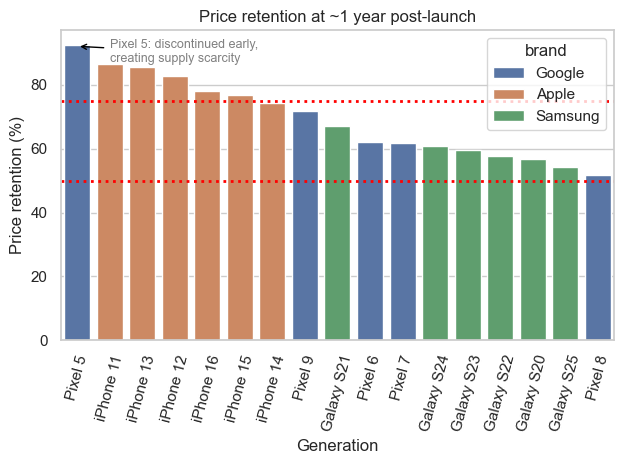

In [14]:
order = retention_1yr_df['generation_name'].tolist()

pd_chart_7 = sns.barplot(
    data=retention_1yr_df,
    x='generation_name',
    y='price_retention',
    hue='brand',
    order=order)

plt.axhline(75, color='red', linestyle='dotted', linewidth=2)
plt.axhline(50, color='red', linestyle='dotted', linewidth=2)
plt.title('Price retention at ~1 year post-launch')
plt.xlabel('Generation')
plt.ylabel('Price retention (%)')
plt.xticks(rotation=75)
plt.tight_layout()

#Annotation
plt.annotate(
    text = 'Pixel 5: discontinued early,\ncreating supply scarcity',
    xy=(0, 92),
    xytext=(1, 87), color = 'gray',
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9
)

plt.show()


iPhones dominate the top of the chart. The Pixel 5 stands out as an anomaly among Google phones. This could be due to the fact that it launched at a low price ($699) and Google discontinued it earlier than expected, which constrained supply and kept its secondary market value unusually stable. Other Pixel models, which launched at
higher prices and remained available for longer, didn't benefit from that same scarcity effect.

---
# Price distribution across the full lifecycle

The decay curves show averages. This boxplot shows the full spread of weekly prices across
the entire recorded lifecycle for each brand: median, quartiles, and outliers. It gives
a sense of how much variation there is within each brand, not just where the average lands.

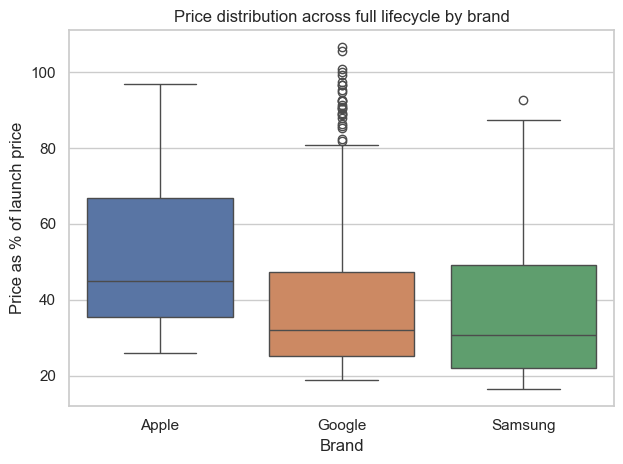

In [15]:
pd_chart_8 = sns.boxplot(
    data=all_brands_decay_df,
    x='brand',
    y='price_pct_of_launch',
    hue='brand')
plt.title('Price distribution across full lifecycle by brand')
plt.xlabel('Brand')
plt.ylabel('Price as % of launch price')
plt.tight_layout()
plt.show()


We can clearly see the Apple products as the highest in terms of median, but also their IQR is placed higher than the competitors. Google and Samsung have very similar plots, with some minor differences, and we can clearly see Google has the highest number of outliers of all three brands.

---
# Monthly sales analysis

Amazon’s monthly_sold metric represents a baseline range rather than an exact number of units sold. For example, a value of 50 means the actual sales fell anywhere between 50 and 99 smartphones.

Because of this, measuring precise sales volumes isn't possible. To work around this limitation, I aggregated the data by taking the last recorded value for each month and summing them up. This allows us to use these numbers as a reliable indicator of relative market performance.

Keepa only started tracking this consistently from late 2023, so there's only about 2 years of data to work with. The data is limited and I was seriously wondering whether to include it, but it should be enough to see some patterns and compare the brands, tiers and some submodels.

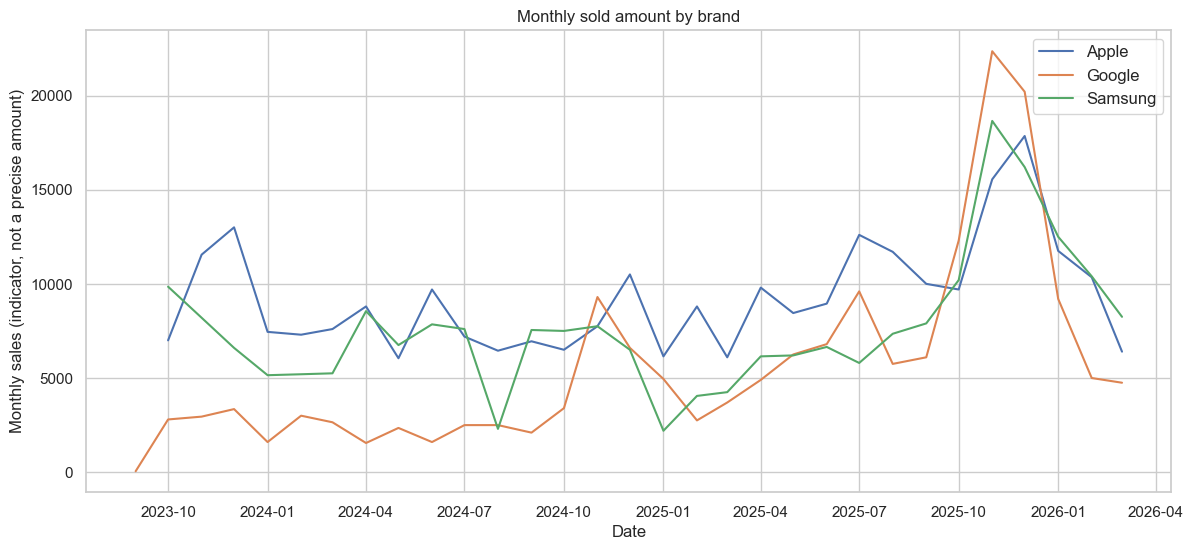

In [ ]:
plt.subplots(figsize = (14, 6))
all_brands_ms_chart = sns.lineplot(
    data = brand_ms_df,
    x = 'month_year',
    y = 'monthly_sold',
    hue = 'brand'
)
plt.title('Monthly sold amount by brand')
plt.ylabel('Monthly sales (indicator, not a precise amount)')
plt.xlabel('Date')
plt.legend(loc = 'upper right', fontsize = 12)
plt.show()






All of the above metrics are only the indicators, and cannot be treated as precise amounts.
We can clearly see that Apple is leading the race being the most popular brand overall, but the differences are not big and often times it was going head to head with Samsung.
Google had a first major rise in Q4 2024, then in July 2025 and finally in Q4 2025, clearly showing that these might be the periods of higher interest.
It's also very interesting to see it at the top of sales in November-December 2025.

All of these brands seem to have a major spike in Q4 2025, and Google and Apple also noted spikes in July 2025.


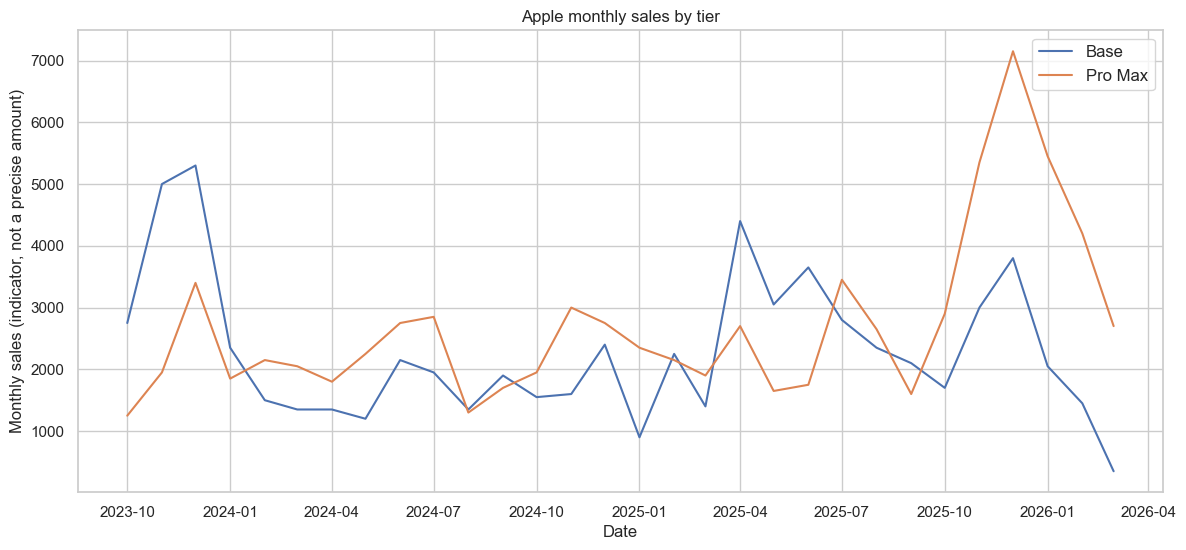

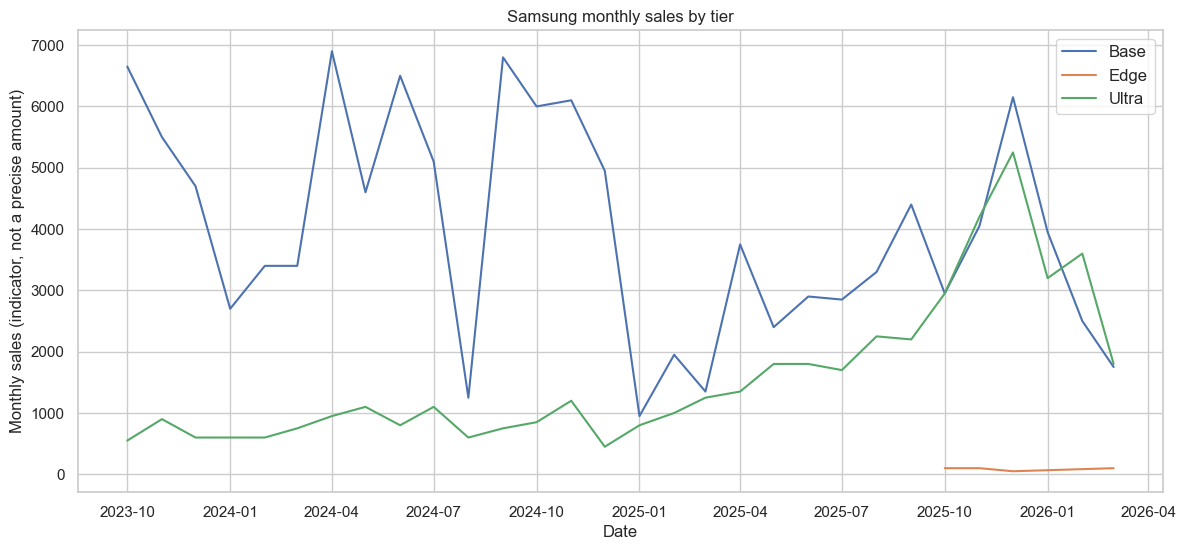

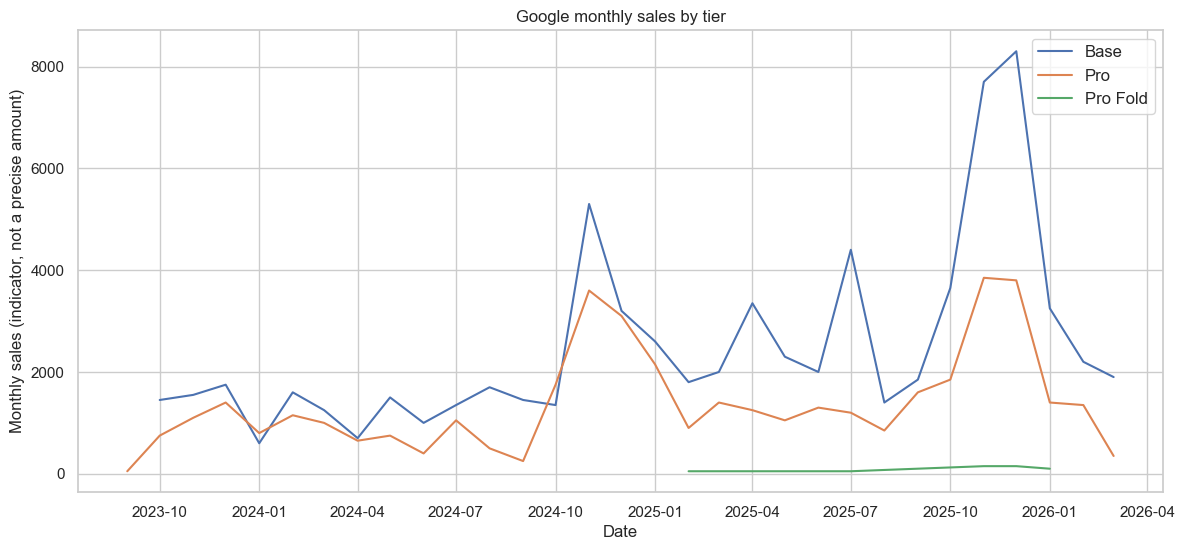

In [17]:

plt.subplots(figsize = (14, 6))
apple_tiers_ms_chart = sns.lineplot(
    data = apple_ms_df,
    x = 'month_year',
    y = 'monthly_sold',
    hue = 'tier'
)
plt.title('Apple monthly sales by tier')
plt.ylabel('Monthly sales (indicator, not a precise amount)')
plt.xlabel('Date')
plt.legend(loc = 'upper right', fontsize = 12)
plt.show()



plt.subplots(figsize = (14, 6))
samsung_tiers_ms_chart = sns.lineplot(
    data = samsung_ms_df,
    x = 'month_year',
    y = 'monthly_sold',
    hue = 'tier'
)
plt.title('Samsung monthly sales by tier')
plt.ylabel('Monthly sales (indicator, not a precise amount)')
plt.xlabel('Date')
plt.legend(loc = 'upper right', fontsize = 12)
plt.show()





plt.subplots(figsize = (14, 6))
google_tiers_ms_chart = sns.lineplot(
    data = google_ms_df,
    x = 'month_year',
    y = 'monthly_sold',
    hue = 'tier'
)
plt.title('Google monthly sales by tier')
plt.ylabel('Monthly sales (indicator, not a precise amount)')
plt.xlabel('Date')
plt.legend(loc = 'upper right', fontsize = 12)
plt.show()

Apple's Base and Pro Max tiers lead interchangeably throughout the observation period. A longer data window would be needed to draw firm conclusions about which tier drives the secondary market more consistently.

Samsung's base tier leads in sales volume for most of the period, though the Ultra version shows a notable spike in Q4 2025. The Edge variant, already flagged for its aggressive price decay, confirms the pattern on the sales side as well, as it sits far below both alternatives throughout the entire observation period.

Google's Base and Pro models run closely together for most of the time, which aligns with the narrow price gap between them observed in the price decay analysis. The Base model spikes sharply in Q4 2025. The Pro Fold, despite being the most expensive smartphone in the entire dataset, shows consistently low sales volume. Its premium price point and niche foldable form factor could limit its reach on the secondary market.

**Sales rank of base iPhones**

Gray dotted lines mark the September iPhone launch window, orange is Black Friday, red is Christmas.
Data starts from late 2023, so there are only two seasonal cycles visible.

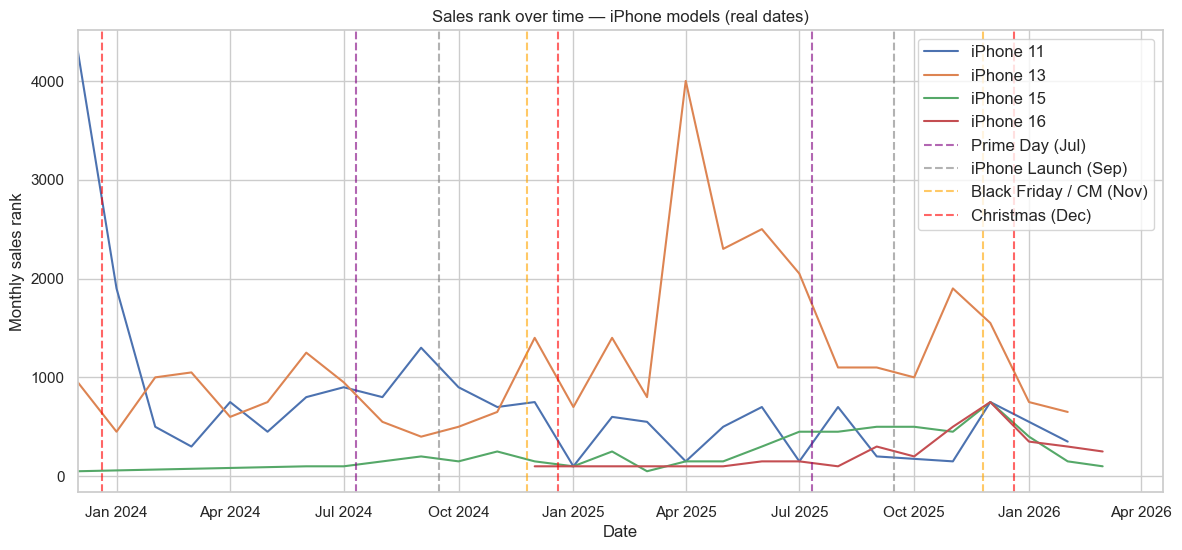

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
ms_chart_5 = sns.lineplot(data=apple_base_ms_df, x='month_year', y='monthly_sold',
    hue='generation_name', ax=ax)

ax.axvline(pd.Timestamp('2023-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6, label='Prime Day (Jul)')
ax.axvline(pd.Timestamp('2023-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='iPhone Launch (Sep)')
ax.axvline(pd.Timestamp('2023-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Black Friday / CM (Nov)')
ax.axvline(pd.Timestamp('2023-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Christmas (Dec)')
for year in range(2024, 2026):
    ax.axvline(pd.Timestamp(f'{year}-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, loc='upper right', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Sales rank over time — iPhone models (real dates)')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly sales rank')
ax.set_xlim(left=pd.Timestamp('2023-12-01'))
plt.show()


## iPhone 13 - the secondary market king
Older models heavily dominate the secondary market early on, with the iPhone 11 and 13 going head-to-head throughout 2024. However, a major shift occurs in 2025, when iPhone 11 sales drop significantly to match the newer iPhone 15 and 16, while the iPhone 13 experiences a massive surge. This clearly establishes the iPhone 13 as the undisputed king of the refurbished market for Apple.

________________________________________________________________________________________________________________________________________________________

Newer models show a slower start on the secondary market and seem to be driven more by specific seasonal triggers.
- Sales of iPhone 15 remain relatively flat during its first year, picking up slightly when the iPhone 16 launches. The real turning point is July 2025 (could be the effect of Prime Day), which sparks an upward sales trend through the end of Q4 2025.
- iPhone 16 follows a similar path but finishes its first year much stronger than the 15. Sales begin climbing right around the premiere of the iPhone 17 and maintain a solid uptrend through the final quarter of 2025.

The data confirms that smartphone sales naturally spike during Q4, and major shopping events like Prime Day provide a noticeable boost to newer generations. Additionally, the launch of a new iPhone generation acts as a catalyst for the sales increase for its immediate predecessors.

However, all of these patterns should be taken with a grain of salt, as we're only looking at 2 years of data.




**Sales rank within a generation for all iPhone 11, 13 and 15 submodels**

At this point, it seems very natural to dig deeper into the respective models to see how their submodels sell.

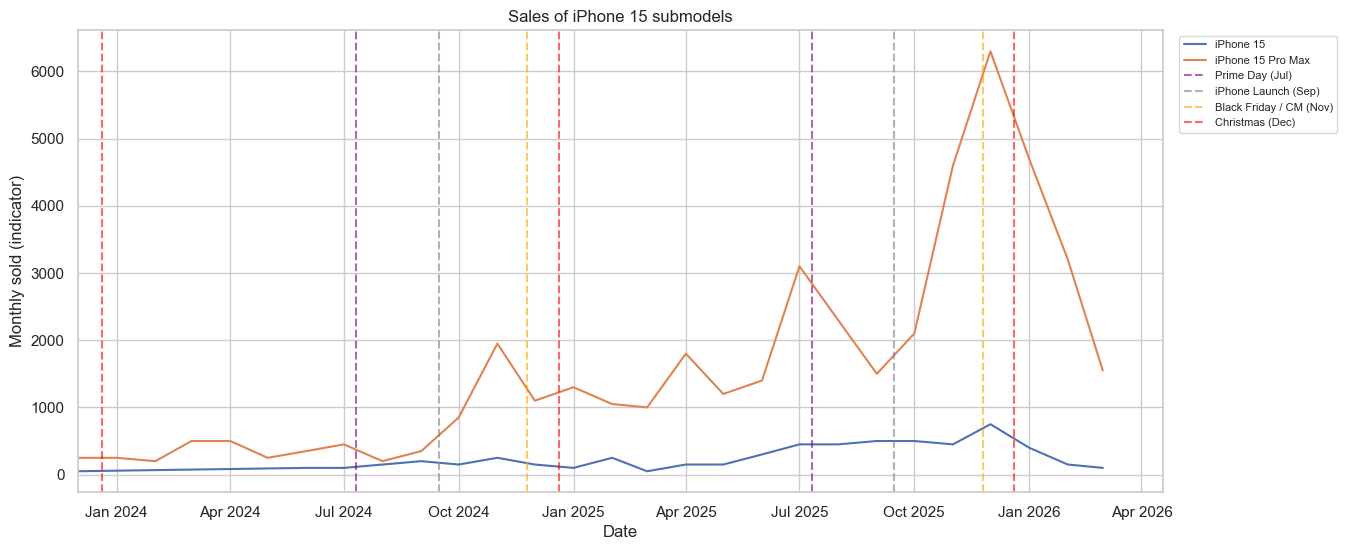

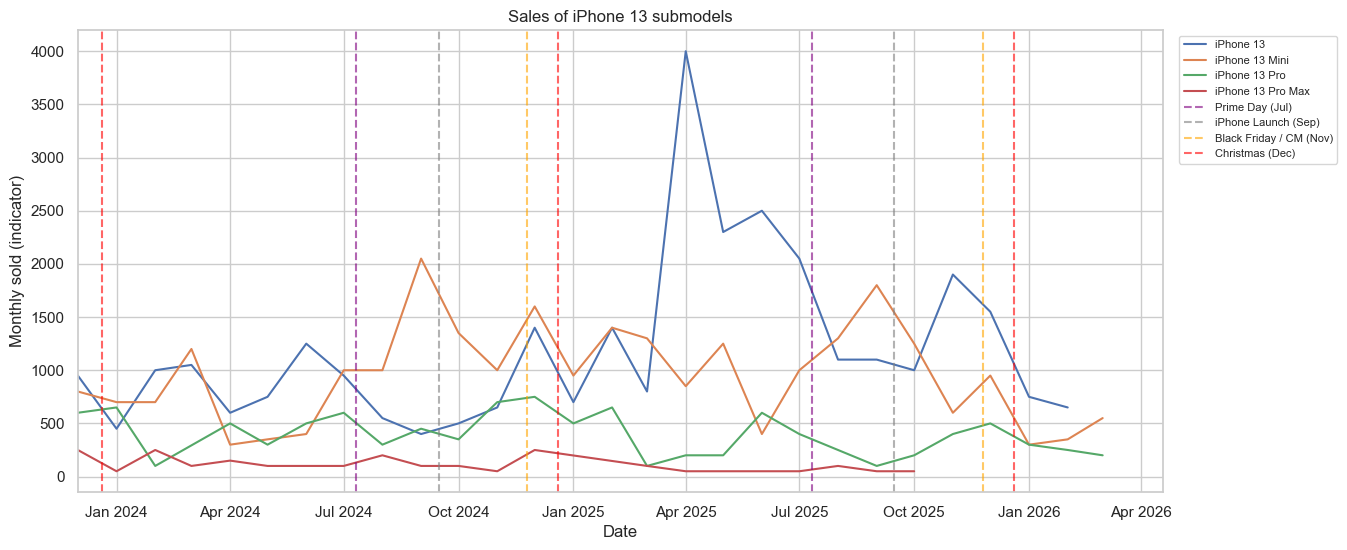

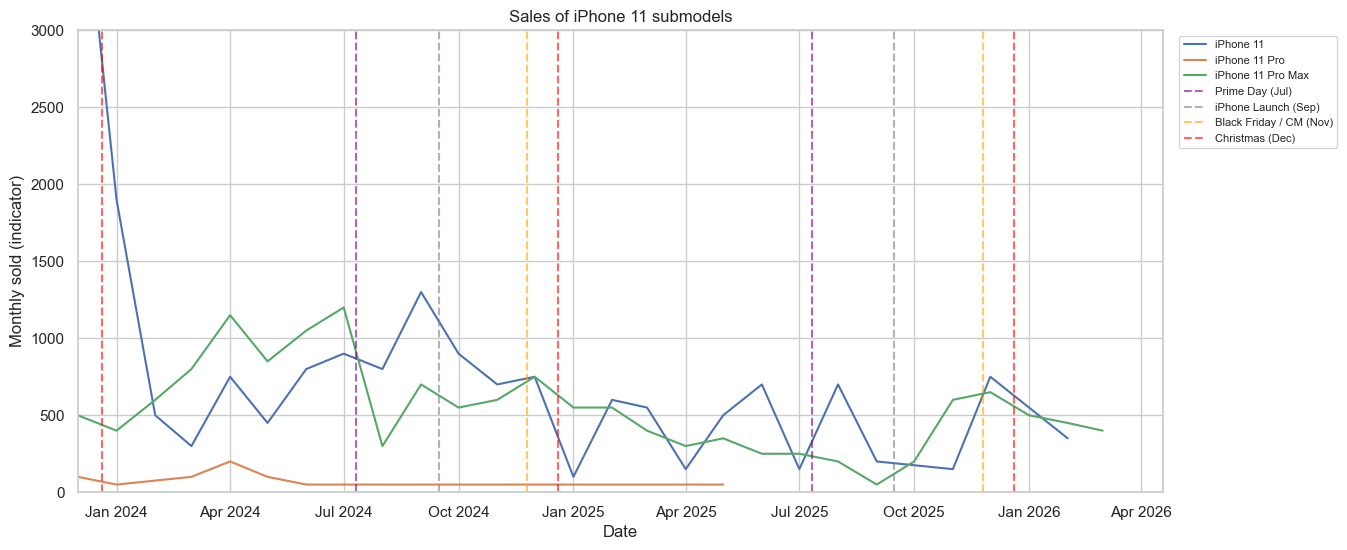

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ms_chart_7 = sns.lineplot(data=iphone15_ms_df, x='month_year', y='monthly_sold',
    hue='submodel_name', ax=ax)

ax.axvline(pd.Timestamp('2023-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6, label='Prime Day (Jul)')
ax.axvline(pd.Timestamp('2023-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='iPhone Launch (Sep)')
ax.axvline(pd.Timestamp('2023-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Black Friday / CM (Nov)')
ax.axvline(pd.Timestamp('2023-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Christmas (Dec)')
for year in range(2024, 2026):
    ax.axvline(pd.Timestamp(f'{year}-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Sales of iPhone 15 submodels')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly sales (indicator, not a precise amount)')
ax.set_xlim(left = pd.Timestamp('2023-12-01'))
plt.show()




fig, ax = plt.subplots(figsize=(14, 6))
ms_chart_6 = sns.lineplot(data=iphone13_ms_df, x='month_year', y='monthly_sold',
    hue='submodel_name', ax=ax)

ax.axvline(pd.Timestamp('2023-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6, label='Prime Day (Jul)')
ax.axvline(pd.Timestamp('2023-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='iPhone Launch (Sep)')
ax.axvline(pd.Timestamp('2023-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Black Friday / CM (Nov)')
ax.axvline(pd.Timestamp('2023-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Christmas (Dec)')
for year in range(2024, 2026):
    ax.axvline(pd.Timestamp(f'{year}-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Sales of iPhone 13 submodels')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly sales (indicator, not a precise amount)')
ax.set_xlim(left = pd.Timestamp('2023-12-01'))
plt.show()




fig, ax = plt.subplots(figsize=(14, 6))
ms_chart_7 = sns.lineplot(data=iphone11_ms_df, x='month_year', y='monthly_sold',
    hue='submodel_name', ax=ax)

ax.axvline(pd.Timestamp('2023-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6, label='Prime Day (Jul)')
ax.axvline(pd.Timestamp('2023-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='iPhone Launch (Sep)')
ax.axvline(pd.Timestamp('2023-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Black Friday / CM (Nov)')
ax.axvline(pd.Timestamp('2023-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Christmas (Dec)')
for year in range(2024, 2026):
    ax.axvline(pd.Timestamp(f'{year}-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Sales of iPhone 11 submodels')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly sales (indicator, not a precise amount)')
ax.set_xlim(left = pd.Timestamp('2023-12-01'))
ax.set_ylim(0, 3000)
plt.show()

## iPhone 15 submodels with the dominance of the Pro Max
The Pro Max version demonstrates significant volatility. Its sales spike immediately after the iPhone 16 launch. We can clearly observe an even sharper rise following the iPhone 17 release, and peak toward the end of 2025. Recently, this growth has slowed down, likely due to the end of the Q4 shopping season.

This behavior suggests that buyers often wait out the first year. Since the Pro Max experiences its sharpest price decay during this initial period, waiting allows consumers to get it while it is still relatively new but already 20–40% cheaper. The premiere of the iPhone 17 drives that price down even further, creating the perfect buying opportunity. In contrast, the base iPhone 15 remains quiet and relatively stable, though it is worth remembering these numbers serve as a performance indicator rather than exact sales figures.

## iPhone 13 with the opposite behavior

This behavior directly contrasts with the older iPhone 13 generation, where the roles are completely reversed. Here, the Pro and the Pro Max act as the stable anchor, while the base model exhibits much higher volatility and stronger sales. In fact, the base version and the Mini lead the race for the iPhone 13 generation. This unexpected finding suggests that buyers looking at older generations could be more driven by price rather than flagship capabilities.

## iPhone 11 as the middle ground for the Pro Max

The iPhone 11 generation serves as a perfect middle ground between the 13 and 15 series. Here, sales of the base model and the Pro Max run almost neck-and-neck.

While the Pro Max maintains a steady price premium over the base version early on, this gap shrinks over time, as well as the Pro Max's price shrinks. Eventually, the difference drops to just about 100 USD, with the Pro Max priced around the 300 USD mark. This creates a clear psychological tipping point: for budget-conscious buyers, saving 100 USD on a base model no longer makes that much sense when they can get the top-tier flagship features for just a fraction more.



---
# Key findings

- **All brands' sales spike in Q4** and there are few factors or events that could affect that. For iPhones, end of September usually signifies the launch of a new generation, and then there's Black Friday (November) and Christmas (December).
- **Apple retains value best.** At the one-year mark, iPhones hold significantly more of their
  launch price than Samsung or Google. The 50% barrier comes around 900 days for Apple vs
  roughly 500 days for Samsung and 420 for Google. This tendency continues throughout the lifecycle.

- **iPhone 13 as the undisputed secondary market king**. Our data shows that this is the best selling iPhone generation on the secondary market at this moment in time.

- **Buying 1-2 years after launch offers strong value. At the one-year mark, iPhones retain roughly 80% of their launch price on average, dropping further to around 60% by year two.** Given that the underlying hardware hasn't meaningfully aged, this represents a compelling entry point - particularly for Pro Max buyers, where the price decay is even more meaningful. Sales data, while limited, seems to support this. More data would be needed to draw firm conclusions.
 
- **Renewed Premium holds its value better than standard Renewed.** For iPhones the gap
  averages around 10.2 percentage points and stays fairly stable
  throughout the lifecycle. It's not just a launch-window premium.

- **New iPhone launches seem to catalyze secondary market sales for predecessors.** Each new generation appears to trigger a measurable uptick in sales for its immediate predecessors. This pattern should be treated as unconfirmed given only two full seasonal cycles are available.

- **The Pixel 5 is an anomaly.** For some reason it outperforms every other Google model at the one-year mark.

- **Some niche variants depreciate fastest.** The Samsung Galaxy Edge and Google Pixel Pro Fold stand out as examples of commercially unsuccessful variants. Both experience some of the sharpest price declines in the dataset and low monthly sales despite their premium positioning. The exact drivers (repair costs, limited appeal, etc.) are speculative and consumer research would be needed to confirm.

- **Budget-conscious buyers drive the secondary market for older generations.** In the iPhone 13 lineup, the base model and the Mini show significantly higher sales than the Pro Max. However, for the iPhone 11, where the prices and the price gap between base and Pro Max have narrowed significantly, the two models sell similarly, suggesting that once the premium shrinks enough, buyers simply opt for the better hardware.

